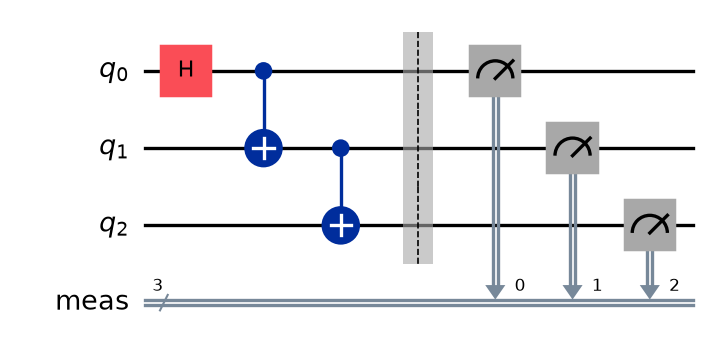

In [1]:
# theres a lot more code from here on out, so I am splitting my notebooks for 3 and 4
# demo 1 - 3.3 - creating a logic circuit first
from qiskit import QuantumCircuit

# Create a logical three-qubit circuit.
qc = QuantumCircuit(3)

# Put qubit 0 into superposition.
qc.h(0)

# Entangle qubit 0 with qubit 1, then qubit 1 with qubit 2.
qc.cx(0, 1)
qc.cx(1, 2)

# Add measurements so the circuit can be sampled.
qc.measure_all()

qc.draw("mpl", scale=1.2)

In [2]:
# demo 2 - 3.3 - connect to IBM quantum via account
from qiskit_ibm_runtime import QiskitRuntimeService

# Run this once in a trusted personal environment. PASTED
# Replace the placeholders with your own IBM Quantum Platform credentials.
# ACCOUNT DATA HIDDEN

# If your account is already saved, this loads it.
service = QiskitRuntimeService()

# Choose an operational real backend with at least 3 qubits.
backend = service.least_busy(
    simulator=False,
    operational=True,
    min_num_qubits=3
)

print("Selected backend:", backend.name)

Selected backend: ibm_fez


In [4]:
# demo 3 - 3.3 - inspect backend
print("Backend:", backend.name)
print("Number of qubits:", backend.num_qubits)
print("Basis gates:", backend.operation_names[:20])
print("Coupling map size:", len(backend.coupling_map.get_edges()))

Backend: ibm_fez
Number of qubits: 156
Basis gates: ['rz', 'cz', 'delay', 'if_else', 'x', 'id', 'sx', 'measure', 'reset']
Coupling map size: 352


In [5]:
# demo 4 - 3.3 - preset pass manager
from qiskit.transpiler import generate_preset_pass_manager

# the passed backend will alert of the harware constraints, then optimization level determines effort for improving circuit
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

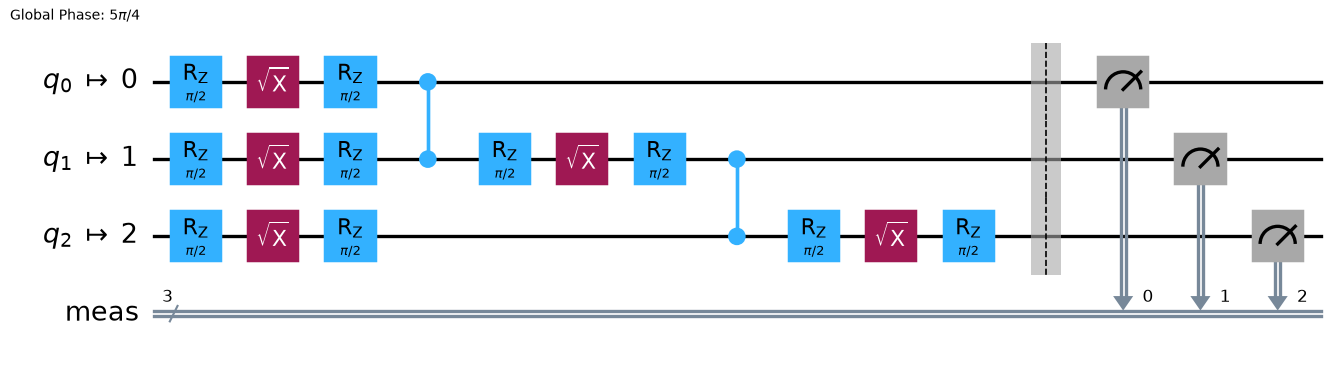

In [7]:
# demo 5 - 3.3 - create ISA circuit
isa_circuit = pm.run(qc)

# the circuit will contain instructed supported by our chosen backend
isa_circuit.draw(
    "mpl",
    idle_wires=False,
    scale=1.2
)

In [8]:
# demo 6 - 3.3 - comparisons
print("Original depth:", qc.depth())
print("Transpiled depth:", isa_circuit.depth())

print("Original operations:")
print(qc.count_ops())

print("Transpiled operations:")
print(isa_circuit.count_ops())

Original depth: 4
Transpiled depth: 12
Original operations:
OrderedDict({'measure': 3, 'cx': 2, 'h': 1, 'barrier': 1})
Transpiled operations:
OrderedDict({'rz': 10, 'sx': 5, 'measure': 3, 'cz': 2, 'barrier': 1})


In [9]:
# demo 7 - 3.3 - understand layout
print(isa_circuit.layout)

TranspileLayout(initial_layout=Layout({
0: <Qubit register=(3, "q"), index=0>,
1: <Qubit register=(3, "q"), index=1>,
2: <Qubit register=(3, "q"), index=2>,
3: <Qubit register=(153, "ancilla"), index=0>,
4: <Qubit register=(153, "ancilla"), index=1>,
5: <Qubit register=(153, "ancilla"), index=2>,
6: <Qubit register=(153, "ancilla"), index=3>,
7: <Qubit register=(153, "ancilla"), index=4>,
8: <Qubit register=(153, "ancilla"), index=5>,
9: <Qubit register=(153, "ancilla"), index=6>,
10: <Qubit register=(153, "ancilla"), index=7>,
11: <Qubit register=(153, "ancilla"), index=8>,
12: <Qubit register=(153, "ancilla"), index=9>,
13: <Qubit register=(153, "ancilla"), index=10>,
14: <Qubit register=(153, "ancilla"), index=11>,
15: <Qubit register=(153, "ancilla"), index=12>,
16: <Qubit register=(153, "ancilla"), index=13>,
17: <Qubit register=(153, "ancilla"), index=14>,
18: <Qubit register=(153, "ancilla"), index=15>,
19: <Qubit register=(153, "ancilla"), index=16>,
20: <Qubit register=(153, "

In [10]:
# demo 8 - 3.3 - run sampler
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

job = sampler.run([isa_circuit], shots=1024)
print("Job ID:", job.job_id())
print("Initial status:", job.status())

Job ID: d99lqbgtcv6s73dng4cg
Initial status: QUEUED


In [12]:
# demo 8 cont - 3.3 - retrieve job results
result = job.result()
pub_result = result[0]

counts = pub_result.data.meas.get_counts()
print(counts)

{'000': 453, '111': 497, '001': 15, '110': 29, '010': 6, '101': 15, '100': 4, '011': 5}


OrderedDict({'rz': 8, 'sx': 5, 'measure': 3, 'ecr': 2, 'x': 1, 'barrier': 1})


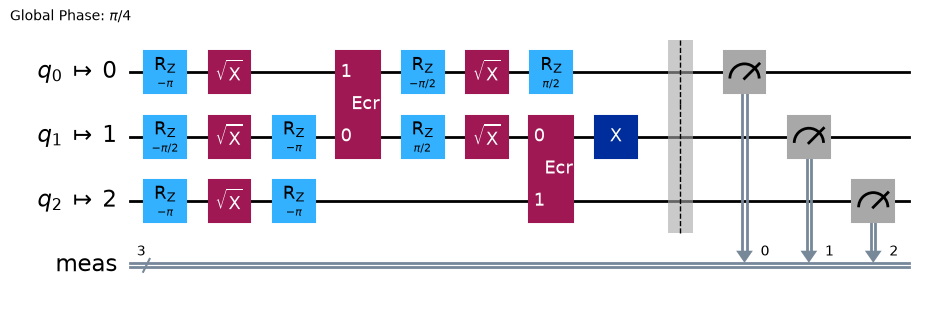

In [13]:
# demo 9 - 3.3 - simulate instead of using hardware
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.transpiler import generate_preset_pass_manager

fake_backend = FakeSherbrooke()

fake_pm = generate_preset_pass_manager(
    backend=fake_backend,
    optimization_level=1
)

fake_isa_circuit = fake_pm.run(qc)

print(fake_isa_circuit.count_ops())
fake_isa_circuit.draw("mpl", idle_wires=False)

In [15]:
# practice: mess with the optimization levels
from qiskit.transpiler import generate_preset_pass_manager

# Choose an operational real backend with at least 3 qubits.
backend = service.least_busy(
    simulator=False,
    operational=True,
    min_num_qubits=3
)

print("Selected backend:", backend.name)

for level in [0, 1, 2, 3]:
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=level
    )
    transpiled = pm.run(qc)

    print("Optimization level:", level)
    print("Depth:", transpiled.depth())
    print("Operations:", transpiled.count_ops())
    print("---")

Selected backend: ibm_fez
Optimization level: 0
Depth: 12
Operations: OrderedDict({'rz': 10, 'sx': 5, 'measure': 3, 'cz': 2, 'barrier': 1})
---
Optimization level: 1
Depth: 12
Operations: OrderedDict({'rz': 10, 'sx': 5, 'measure': 3, 'cz': 2, 'barrier': 1})
---
Optimization level: 2
Depth: 10
Operations: OrderedDict({'rz': 8, 'sx': 5, 'measure': 3, 'cz': 2, 'barrier': 1})
---
Optimization level: 3
Depth: 10
Operations: OrderedDict({'rz': 8, 'sx': 5, 'measure': 3, 'cz': 2, 'barrier': 1})
---


{'11': 2027, '00': 2069}


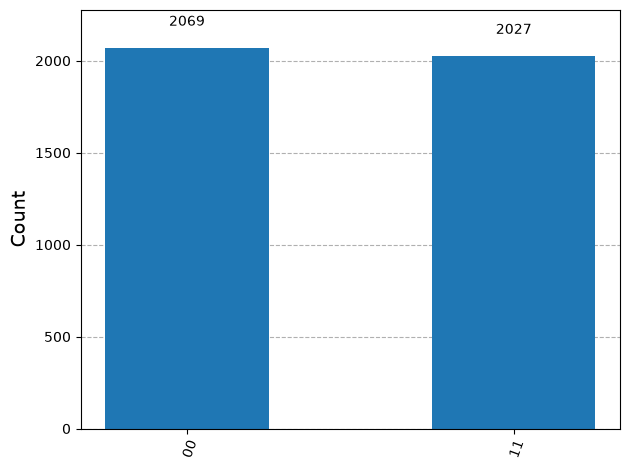

In [24]:
# part 3.4
# demo 1 - local example with sampler
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

# Create a Bell-state circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

# Run the circuit with the local statevector sampler
sampler = StatevectorSampler(seed=123)
job = sampler.run([bell], shots=4096)
result = job.result()

# measure_all() creates a classical register usually called "meas"
counts = result[0].data.meas.get_counts()
print(counts)

plot_histogram(counts)

In [27]:
# demo 2 - 3.4 - local example with estimator
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# Prepare the same Bell state, but without measurement operations
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Define Pauli observables
observables = [
    SparsePauliOp("ZZ"),
    SparsePauliOp("ZI"),
    SparsePauliOp("IZ"),
    SparsePauliOp("XX"),
    SparsePauliOp("YY")
]

estimator = StatevectorEstimator()
job = estimator.run([(qc, observables)])
result = job.result()[0]

print("Expectation values:", result.data.evs)

Expectation values: [ 1.  0.  0.  1. -1.]


In [18]:
# demo 3 - 3.4 - parameterized estimator example
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

theta = Parameter("theta")

ansatz = QuantumCircuit(1)
ansatz.ry(theta, 0)

observable = SparsePauliOp("Z")
parameter_values = [[0], [np.pi / 2], [np.pi]]

estimator = StatevectorEstimator()
job = estimator.run([(ansatz, observable, parameter_values)])
result = job.result()[0]

print("Parameter values:", parameter_values)
print("Expectation values:", result.data.evs)

Parameter values: [[0], [1.5707963267948966], [3.141592653589793]]
Expectation values: [ 1.  0. -1.]


In [19]:
# demo 4 - 3.4 - testing on IBM, again
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True,
    simulator=False
)

print("Selected backend:", backend.name)

Selected backend: ibm_marrakesh


In [20]:
# continued
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Circuit to sample
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

# Convert the circuit into a backend-compatible ISA circuit
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)
isa_circuit = pm.run(bell)

# Execute with Runtime SamplerV2
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1024)
print("Job ID:", job.job_id())

result = job.result()
counts = result[0].data.meas.get_counts()
print(counts)

Job ID: d99mnigtcv6s73dnh79g
{'00': 493, '11': 508, '01': 12, '10': 11}


In [21]:
# demo 5 - 3.4 - estimator on IBM, also WOW it takes 12s compared to the 2s for a sampler
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# State-preparation circuit without measurements
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

observable = SparsePauliOp("ZZ")

# Transpile the circuit for the selected backend
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)
isa_circuit = pm.run(qc)

# Match the observable to the physical qubit layout chosen by the transpiler
isa_observable = observable.apply_layout(isa_circuit.layout)

# Execute with Runtime EstimatorV2
estimator = Estimator(mode=backend)
job = estimator.run([(isa_circuit, isa_observable)])
print("Job ID:", job.job_id())

result = job.result()[0]
print("Estimated expectation value:", result.data.evs)

Job ID: d99moesqp3as739uban0
Estimated expectation value: 0.9829488465396189


In [22]:
# demo 6 - 3.4 - options
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime.options import EstimatorOptions

options = EstimatorOptions()
options.resilience_level = 1

estimator = Estimator(
    mode=backend,
    options=options
)